In [1]:
# review of 01_first_look: setup and load
import sys, time, json, subprocess
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path("/projects/ancz7294/yjmob")
RAW, PROC, FIG = ROOT / "data/raw", ROOT / "data/processed", ROOT / "figures"
N_PEOPLE, N_DAYS, N_SLOTS = 25000, 75, 48

t0 = time.time()
yj = pd.read_csv(RAW / "yjmob100k-dataset2.csv.gz", engine="pyarrow",
                 dtype={"uid": "int32", "d": "int16", "t": "int16", "x": "int16", "y": "int16"})
print(f"loaded {len(yj):,} rows in {time.time()-t0:.1f} s")

# share of people observed, one row per day, one column per half-hour slot
M = yj.groupby(["d", "t"]).size().unstack(fill_value=0).to_numpy() / N_PEOPLE
days = pd.DataFrame({"d": np.arange(N_DAYS)})
days["mod7"] = days.d % 7
days["flag_01"] = days.mod7.isin([0, 6])          # the weekend-like flag used in notebook 01
days["coverage"] = M.mean(axis=1)

# the rule came from days 0-59. Does it still pick the low days at the end?
print("\nlast four weeks, * = flagged weekend-like in notebook 01")
for start in (47, 54, 61, 68):
    wk = days.iloc[start:start + 7]
    print("  ".join(f"{r.d:>2}{'*' if r.flag_01 else ' '} {r.coverage:.3f}" for r in wk.itertuples()))

loaded 29,389,749 rows in 3.9 s

last four weeks, * = flagged weekend-like in notebook 01
47  0.354  48* 0.308  49* 0.272  50  0.295  51  0.351  52  0.350  53  0.349
54  0.356  55* 0.310  56* 0.276  57  0.347  58  0.355  59  0.352  60  0.313
61  0.317  62* 0.321  63* 0.327  64  0.332  65  0.280  66  0.237  67  0.263
68  0.318  69* 0.322  70* 0.322  71  0.326  72  0.271  73  0.229  74  0.306


## Review of notebook 01: does the weekend rule hold to the end?

Before writing up the EDA I went back over the per-day coverage from notebook 01. The rule "d mod 7 in {0, 6} is weekend-like" was read off days 0-59, and there it fits: the two flagged days of every week are the low ones. After day 60 it does not. The flagged days 62, 63, 69 and 70 are as high as the days around them, and the two-day dips fall on 65, 66 and 72, 73, which the rule calls weekdays. The weekly rhythm is still visible, it is just not where the rule expects it. Coverage is lower everywhere in the emergency, so the next check uses the shape of the day, not its level.

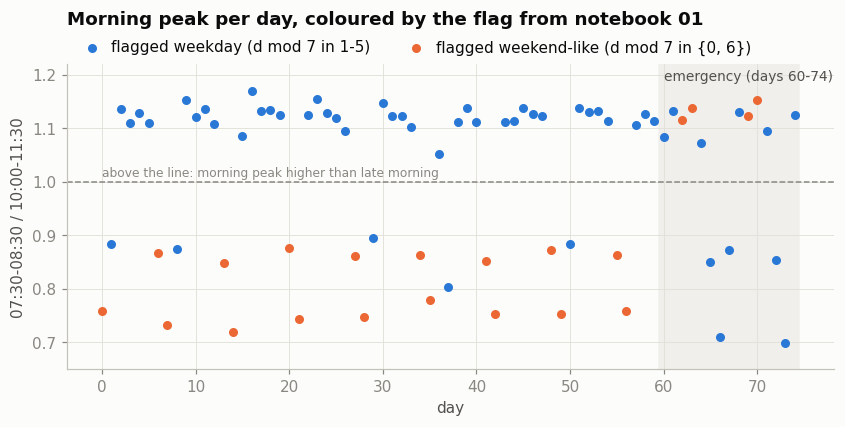

In [3]:
# a measure of the shape of the day, independent of how many people are seen:
# observation rate 07:30-08:30 (slots 15-16) divided by 10:00-11:30 (slots 20-22)
days["morning_ratio"] = M[:, 15:17].mean(axis=1) / M[:, 20:23].mean(axis=1)

C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": "#0b0b0b", "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.family": "sans-serif", "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight"})

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.axvspan(59.5, 74.5, color="#f0efec", zorder=0)
ax.axhline(1, color="#898781", lw=1, ls="--")
for flag, col, lab in [(False, C[0], "flagged weekday (d mod 7 in 1-5)"), (True, C[1], "flagged weekend-like (d mod 7 in {0, 6})")]:
    s = days[days.flag_01 == flag]
    ax.scatter(s.d, s.morning_ratio, color=col, s=24, label=lab, zorder=3)
ax.text(60, 1.19, "emergency (days 60-74)", color="#52514e", fontsize=9)
ax.text(0, 1.005, "above the line: morning peak higher than late morning", color="#898781", fontsize=8, va="bottom")
ax.set(xlabel="day", ylabel="07:30-08:30 / 10:00-11:30", ylim=(0.65, 1.22))
ax.set_title("Morning peak per day, coloured by the flag from notebook 01", pad=26)
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, borderaxespad=0.2, handletextpad=0.3)
plt.show()

In [4]:
print("gap between the two groups: highest ratio below 1 =", days.morning_ratio[days.morning_ratio < 1].max().round(2),
      "| lowest ratio above 1 =", days.morning_ratio[days.morning_ratio > 1].min().round(2))
days["looks_restday"] = days.morning_ratio < 1
bad = days[days.looks_restday != days.flag_01]
print("\ndays where the flag and the shape of the day disagree:")
print(bad[["d", "mod7", "flag_01", "coverage", "morning_ratio"]].round(3).to_string(index=False))

gap between the two groups: highest ratio below 1 = 0.9 | lowest ratio above 1 = 1.05

days where the flag and the shape of the day disagree:
 d  mod7  flag_01  coverage  morning_ratio
 1     1    False     0.293          0.884
 8     1    False     0.300          0.875
29     1    False     0.307          0.896
37     2    False     0.297          0.804
50     1    False     0.295          0.885
62     6     True     0.321          1.115
63     0     True     0.327          1.137
65     2    False     0.280          0.850
66     3    False     0.237          0.710
67     4    False     0.263          0.872
69     6     True     0.322          1.123
70     0     True     0.322          1.154
72     2    False     0.271          0.854
73     3    False     0.229          0.699


## The shape of the day separates workdays from rest days

The ratio of the 07:30-08:30 observation rate to the 10:00-11:30 rate does not depend on how many people are seen overall. Every one of the 75 days falls into one of two bands: above 1.05, with a morning peak, or below 0.90, without one. Nothing lies in between. On days 0-59 all flagged weekend-like days sit in the lower band, as they should. After day 60 the flagged days 62, 63, 69 and 70 sit in the upper band with the workdays, and 65, 66, 72 and 73 sit in the lower band. The list also shows six days that notebook 01 missed: 1, 8, 29, 37, 50 and 67 are on a weekday phase but have no morning peak and low coverage, like a public holiday. This is still one signal, the timing of observations, so the next check uses location instead.

home cell found for 24,245 of 25,000 people


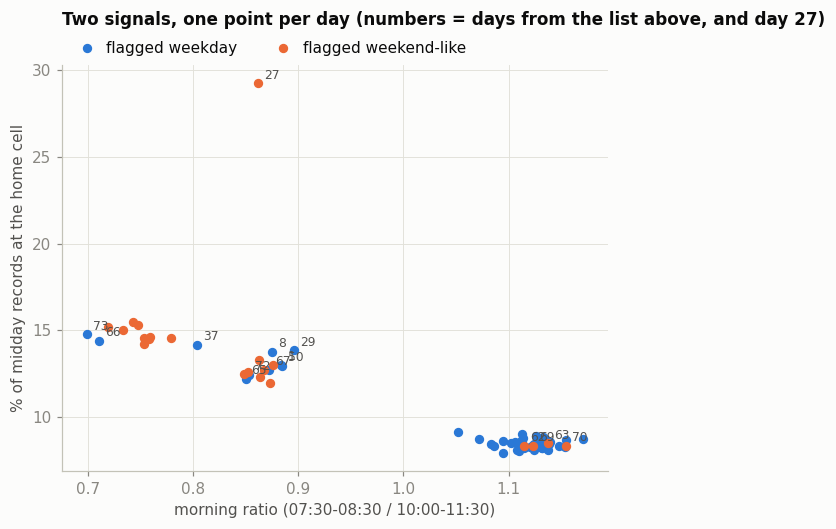

                       coverage  morning_ratio  midday_home
flag_01 looks_restday                                      
False   False             0.352          1.121        0.085
        True              0.277          0.833        0.134
True    False             0.323          1.132        0.084
        True              0.291          0.803        0.148

the numbered days:
 d  mod7  flag_01  morning_ratio  midday_home
 1     1    False          0.884        0.130
 8     1    False          0.875        0.138
27     6     True          0.862        0.293
29     1    False          0.896        0.138
37     2    False          0.804        0.142
50     1    False          0.885        0.130
62     6     True          1.115        0.084
63     0     True          1.137        0.085
65     2    False          0.850        0.122
66     3    False          0.710        0.144
67     4    False          0.872        0.127
69     6     True          1.123        0.083
70     0     True     

In [6]:
# second, independent signal: where people are at midday.
# home cell = a person's most frequent cell between 00:00 and 06:00 on days 0-59
night = yj[(yj.t < 12) & (yj.d < 60)]
cell = night.x.astype("int32") * 1000 + night.y
home = pd.DataFrame({"uid": night.uid.to_numpy(), "cell": cell.to_numpy()}).groupby("uid").cell.agg(lambda s: s.value_counts().index[0])
print(f"home cell found for {len(home):,} of {N_PEOPLE:,} people")

mid = yj[(yj.t >= 20) & (yj.t < 32)]                                   # 10:00-16:00
at_home = (mid.x.astype("int32") * 1000 + mid.y).to_numpy() == mid.uid.map(home).to_numpy()
known = mid.uid.isin(home.index).to_numpy()
days["midday_home"] = pd.Series(at_home[known]).groupby(mid.d.to_numpy()[known]).mean().to_numpy()

fig, ax = plt.subplots(figsize=(6.4, 4.8))
for flag, col, lab in [(False, C[0], "flagged weekday"), (True, C[1], "flagged weekend-like")]:
    s = days[days.flag_01 == flag]
    ax.scatter(s.morning_ratio, s.midday_home * 100, color=col, s=26, label=lab, zorder=3)
for r in days[(days.looks_restday != days.flag_01) | (days.d == 27)].itertuples():
    ax.annotate(str(r.d), (r.morning_ratio, r.midday_home * 100), xytext=(4, 3), textcoords="offset points", fontsize=8, color="#52514e")
ax.set(xlabel="morning ratio (07:30-08:30 / 10:00-11:30)", ylabel="% of midday records at the home cell")
ax.set_title("Two signals, one point per day (numbers = days from the list above, and day 27)", pad=26, fontsize=11)
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, borderaxespad=0.2, handletextpad=0.3)
plt.show()

print(days.groupby(["flag_01", "looks_restday"])[["coverage", "morning_ratio", "midday_home"]].mean().round(3))
print("\nthe numbered days:")
print(days.loc[(days.looks_restday != days.flag_01) | (days.d == 27),
               ["d", "mod7", "flag_01", "morning_ratio", "midday_home"]].round(3).to_string(index=False))

## A second signal agrees: where people are at midday

For 24,245 people a home cell can be set as their most frequent cell between 00:00 and 06:00 on days 0-59. On workdays about 8.5% of the records between 10:00 and 16:00 are at that cell; on rest days it is 12 to 15%. This uses location, not the timing of observations, and it sorts the days the same way as the morning ratio. Days 62, 63, 69 and 70 sit with the workdays (8.4%), days 65, 66, 72 and 73 with the rest days, and so do 1, 8, 29, 37, 50 and 67. Inside the rest days the two weekend days differ: the second one is quieter (ratio about 0.75, 15% at home) than the first (0.86, 13%), and 65/66 and 72/73 repeat that order. Day 27 is a separate case: 29% at home and the lowest coverage of all 75 days. Notebook 01 placed it on a weekday phase, but 27 mod 7 = 6, so it is a weekend-like day that was far quieter than any other.

In [7]:
# which weekly alignment fits days 60-74?
# template = median profile of each d mod 7 on days 0-59 (each day's 48 slots scaled to sum to 1, so only the shape counts)
P = M / M.sum(axis=1, keepdims=True)
d = days.d.to_numpy()
T = np.array([np.median(P[:60][d[:60] % 7 == p], axis=0) for p in range(7)])
ratio_T = days.iloc[:60].groupby("mod7").morning_ratio.median().to_numpy()

def fit(block, shift):
    ph = (d[block] + shift) % 7
    rmse = np.sqrt(((P[block] - T[ph]) ** 2).mean()) * 1e3
    return rmse, np.corrcoef(ratio_T[ph], days.morning_ratio.to_numpy()[block])[0, 1]

print("shift   days 45-59 (control)      days 60-74")
print("        rmse x1000   corr         rmse x1000   corr")
for s in range(7):
    a, b = fit(slice(45, 60), s), fit(slice(60, 75), s)
    print(f"  {s}      {a[0]:6.3f}    {a[1]:6.2f}          {b[0]:6.3f}    {b[1]:6.2f}")

shift   days 45-59 (control)      days 60-74
        rmse x1000   corr         rmse x1000   corr
  0       0.463      0.95           2.137     -0.53
  1       1.322      0.35           2.130     -0.50
  2       1.843     -0.37           2.062     -0.32
  3       1.999     -0.57           1.674      0.36
  4       2.072     -0.55           0.971      0.94
  5       1.809     -0.26           1.591      0.37
  6       1.224      0.52           2.044     -0.34


## The weekly rhythm shifts by four days at day 60

Each day's profile was scaled to sum to 1 and compared with the median profile of every d mod 7 on days 0-59, for all seven possible shifts. On the control block, days 45-59, shift 0 fits best (rmse 0.46, correlation 0.95), so the test finds the alignment that is known to be right there. On days 60-74 shift 0 is the worst of the seven and shift 4 is clearly the best (rmse 0.97, correlation 0.94, next best 1.59 and 0.37). With phase = (d + 4) mod 7 from day 60 on, days 65 and 72 land on phase 6 and days 66 and 73 on phase 0, the same two-day weekend in the same order as before. The dataset paper withholds dates and does not say whether days 60-74 follow day 59 on the calendar, so the shift is reported as an observed property of the data without an explanation.

In [9]:
# apply the corrected day typing and compare like with like
days["phase"] = np.where(days.d < 60, days.d % 7, (days.d + 4) % 7)
days["weekend"] = days.phase.isin([0, 6])
days["holiday_like"] = days.d.isin([1, 8, 29, 37, 50, 67])
days["workday"] = ~days.weekend & ~days.holiday_like
assert ((days.morning_ratio > 1) == days.workday).all()            # the typing now agrees with the shape of every day
print("day typing agrees with the morning ratio on all 75 days")

days["kind"] = np.select([days.workday, days.holiday_like, days.phase == 6], ["workday", "holiday-like", "weekend day 1"], "weekend day 2")
days["period"] = np.where(days.d < 60, "days 0-59", "days 60-74")
tab = days[days.d != 27].groupby(["kind", "period"]).agg(n_days=("d", "size"), coverage=("coverage", "mean"), morning_ratio=("morning_ratio", "mean"),
                                                         midday_home=("midday_home", "mean")).round(3)
print(tab.to_string())
cv = tab.coverage.unstack()
print("\ncoverage change in the emergency, same kind of day:"); print(((cv["days 60-74"] / cv["days 0-59"] - 1) * 100).round(1).astype(str) + " %")
print("\nday 27 (phase 6, left out above):", days.loc[[27], ["coverage", "morning_ratio", "midday_home"]].round(3).iloc[0].to_dict())

day typing agrees with the morning ratio on all 75 days
                          n_days  coverage  morning_ratio  midday_home
kind          period                                                  
holiday-like  days 0-59        5     0.299          0.869        0.135
              days 60-74       1     0.263          0.872        0.127
weekend day 1 days 0-59        7     0.314          0.863        0.126
              days 60-74       2     0.275          0.852        0.123
weekend day 2 days 0-59        9     0.280          0.750        0.148
              days 60-74       2     0.233          0.705        0.146
workday       days 0-59       38     0.357          1.123        0.085
              days 60-74      10     0.320          1.117        0.083

coverage change in the emergency, same kind of day:
kind
holiday-like     -12.0 %
weekend day 1    -12.4 %
weekend day 2    -16.8 %
workday          -10.4 %
dtype: object

day 27 (phase 6, left out above): {'coverage': 0.226, 'mornin

## Corrected day typing, and what the emergency changes

Decisions: the weekly phase is d mod 7 on days 0-59 and (d + 4) mod 7 on days 60-74, with phases {0, 6} weekend-like. Days 1, 8, 29, 37, 50 and 67 get a separate holiday_like flag, and a workday is a day that is neither. With this typing the morning ratio agrees with the day type on all 75 days. Comparing the same kind of day before and after day 60, coverage falls on every kind: 10.4% on workdays (0.357 to 0.320), 12 to 17% on rest days, where the emergency has only one or two days of each kind. The shape of the day stays the same. Workdays keep their morning peak (ratio 1.12 before and after) and the same share of midday records at home (8.5% and 8.3%). Notebook 01 concluded that emergency weekdays lose the 8 am peak and look like weekends; that came from the misplaced flag, which put four weekend days and a holiday-like day into the emergency "weekday" group. Day 27 is left out of the averages: it is on phase 6 but far quieter than any weekend (coverage 0.226, 29% at home).

In [10]:
# sweep of the whole day x slot grid: each day's profile (scaled to sum to 1) against the median profile of its kind of day on days 0-59
P = M / M.sum(axis=1, keepdims=True)
ord_ = (days.d < 60) & (days.d != 27)
tmpl = {k: np.median(P[(ord_ & (days.kind == k)).to_numpy()], axis=0) for k in days.kind.unique()}
R = np.array([P[i] / tmpl[k] for i, k in enumerate(days.kind)])
hits = pd.DataFrame([(i, j, M[i, j], R[i, j]) for i, j in zip(*np.where((R < 0.75) | (R > 1.25)))], columns=["d", "slot", "share_observed", "vs_template"])
hits["time"] = (hits.slot // 2).astype(str).str.zfill(2) + ":" + np.where(hits.slot % 2 == 0, "00", "30")
print(hits.groupby("d").agg(slots=("slot", "size"), first=("time", "first"), last=("time", "last"), lowest=("vs_template", "min"), highest=("vs_template", "max")).round(2).to_string())
print("\n00:00 slot, mean share observed: days 0-59", M[:60, 0].mean().round(3), "| days 60-74", M[60:, 0].mean().round(3))
print("00:30 slot, mean share observed: days 0-59", M[:60, 1].mean().round(3), "| days 60-74", M[60:, 1].mean().round(3))
print("\nday 66, 22:00 to 23:30:", M[66, 44:48].round(3), "| day 73, same slots:", M[73, 44:48].round(3))

    slots  first   last  lowest  highest
d                                       
27     12  00:00  05:30    1.27     1.50
60      1  00:00  00:00    0.68     0.68
65      1  00:00  00:00    0.75     0.75
66      2  23:00  23:30    0.09     0.71
68      1  00:00  00:00    0.72     0.72
74      1  00:00  00:00    0.70     0.70

00:00 slot, mean share observed: days 0-59 0.138 | days 60-74 0.093
00:30 slot, mean share observed: days 0-59 0.142 | days 60-74 0.12

day 66, 22:00 to 23:30: [0.178 0.13  0.014 0.095] | day 73, same slots: [0.169 0.15  0.14  0.127]


## Slot-level sweep: two recording artefacts, nothing else

Every day's profile was compared with the median profile of its kind of day on days 0-59, and every half-hour slot more than 25% off was listed. Apart from day 27, whose night slots only stand out because its daytime is so empty, two things appear. Day 66 has a recording gap at 23:00: 1.4% of people observed against 14% on day 73, the matching day a week later, with 23:30 still low. And the first slot of the day is thinner in the whole emergency block: 9.3% observed at 00:00 against 13.8% on days 0-59, a drop of a third when the day as a whole drops 10 to 17%, and 00:30 is lower too. Both are properties of the recording, not of behaviour. They are documented here and no records are removed.

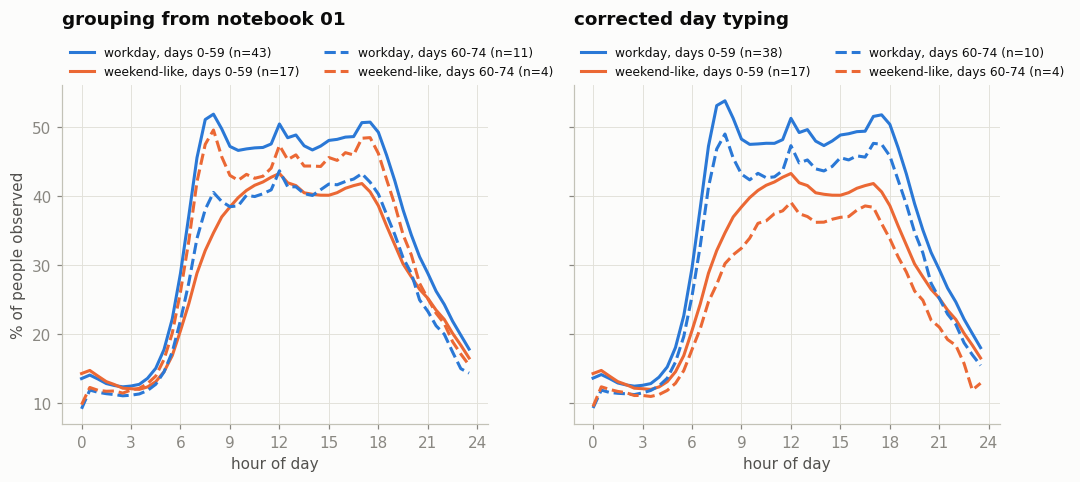

workday 0-59                   08:00 53.8%   12:00 51.2%   highest at 08.0 h
workday 60-74, corrected       08:00 49.0%   12:00 47.3%   highest at 08.0 h
'weekday' 60-74, notebook 01   08:00 40.5%   12:00 43.7%   highest at 12.0 h
days behind the notebook 01 emergency 'weekday' curve: [60, 61, 64, 65, 66, 67, 68, 71, 72, 73, 74]


In [11]:
# what the correction does to the time-of-day picture (f02): notebook 01 grouping on the left, corrected on the right
def curve(mask): return M[mask.to_numpy()].mean(axis=0) * 100
hours = np.arange(N_SLOTS) / 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
old_wd, new_wd, emg = ~days.flag_01, days.workday, days.d >= 60
for ax, wd, we, title in [(axes[0], old_wd, days.flag_01, "grouping from notebook 01"), (axes[1], new_wd, days.weekend, "corrected day typing")]:
    for lab, mask, col, ls in [("workday, days 0-59", wd & ~emg, C[0], "-"), ("weekend-like, days 0-59", we & ~emg, C[1], "-"),
                               ("workday, days 60-74", wd & emg, C[0], "--"), ("weekend-like, days 60-74", we & emg, C[1], "--")]:
        ax.plot(hours, curve(mask), color=col, ls=ls, lw=2, label=f"{lab} (n={mask.sum()})")
    ax.set(xlabel="hour of day", xticks=range(0, 25, 3)); ax.set_title(title, pad=40)
    ax.legend(frameon=False, fontsize=8, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, borderaxespad=0.2)
axes[0].set_ylabel("% of people observed"); plt.show()

for lab, mask in [("workday 0-59", new_wd & ~emg), ("workday 60-74, corrected", new_wd & emg), ("'weekday' 60-74, notebook 01", old_wd & emg)]:
    c = curve(mask); print(f"{lab:30s} 08:00 {c[16]:.1f}%   12:00 {c[24]:.1f}%   highest at {c.argmax()/2:04.1f} h")
print("days behind the notebook 01 emergency 'weekday' curve:", days.d[old_wd & emg].tolist())

## The time-of-day figure, before and after the correction

With the grouping from notebook 01 (left), the emergency "workday" curve has no morning peak and tops out at noon, and the emergency "weekend" curve has a commute peak that no ordinary weekend has. Both are mixtures: the first averages 65, 66, 67, 72 and 73 in with real workdays, the second consists of four workdays (62, 63, 69, 70). With the corrected typing (right) each emergency curve is a lower copy of its ordinary curve. Workdays still peak at 08:00, at 49.0% of people observed against 53.8%, and the gap is 4 to 5 points through the day and close to zero at night. The ordinary workday curve is also a little sharper than in notebook 01 because the five holiday-like days are no longer averaged into it. The two recording artefacts from the sweep are visible here: both emergency curves start low at 00:00, and the emergency weekend curve has a notch at 23:00 from day 66.

In [12]:
# keep the script from notebook 01 before replacing it
import shutil
if not (ROOT / "code/prep_v1.py").exists(): shutil.copy(ROOT / "code/prep.py", ROOT / "code/prep_v1.py")
print("backup:", (ROOT / "code/prep_v1.py").exists(), "| size", (ROOT / "code/prep_v1.py").stat().st_size, "bytes")

backup: True | size 7157 bytes


In [13]:
%%writefile /projects/ancz7294/yjmob/code/prep.py
"""Data preparation for 'Agent reliability under disruption'.
Derived from notebooks/01_first_look.ipynb (2026-09-17). Reproduces the processed tables from the raw files.
Decisions (see notebook): nothing is deleted from YJMob; records are flagged. Windows fit 0-44 / val 45-59 / fb 60-66 / tgt 67-74.
Weekly phase (corrected 2026-09-17, notebooks/02_review_and_fix.ipynb): d mod 7 on days 0-59, (d + 4) mod 7 on days 60-74, because
the weekly rhythm of the emergency block is shifted by 4 days. Phases {0, 6} are weekend-like. Days 1, 8, 29, 37, 50 and 67 sit on a
weekday phase but run like a rest day and are flagged holiday_like. The script checks this day typing against the data and stops if
it does not hold. Split 70/30 by uid, seed 20260917. Eligibility: >= 20 adjacent pairs in every window.
Flags: adjacent (gap 1 slot), big_jump (> 100 cells in 30 min), flicker_mid (middle of a one-cell A-B-A). Foursquare: exact
duplicates dropped, JST local time for all rows (tz_flag), names normalised, 500 m local grid, coarse groups from the reviewed csv.
Usage: python prep.py [--root /projects/ancz7294/yjmob]
"""
import argparse, hashlib, zipfile, json, time
from pathlib import Path
import numpy as np, pandas as pd

SEED, N_PEOPLE = 20260917, 25000
SHIFT_FROM, SHIFT = 60, 4                      # weekly phase = (d + SHIFT) mod 7 from day SHIFT_FROM on
HOLIDAY_LIKE = [1, 8, 29, 37, 50, 67]          # weekday phase, no morning peak
MD5 = {"yjmob100k-dataset2.csv.gz": "ec769fafa7a746caa3d48d2844b9735c", "cell_POIcat.csv.gz": "93af4bb0b417cd20e95fdc1d8f7b459f",
       "POI_datacategories.csv": "fd024e10c1d1dd91356d010413ace390", "foursquare/dataset_tsmc2014.zip": "a9534dc06f0495b36f216017d2f47701"}

def md5(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(1 << 22), b""): h.update(b)
    return h.hexdigest()

def day_table(yj):
    """One row per day: corrected weekly phase, day type and the two signals the day typing is checked against."""
    m = yj.groupby(["d", "t"]).size().unstack(fill_value=0).to_numpy() / N_PEOPLE
    dt = pd.DataFrame({"d": np.arange(len(m), dtype="int16")})
    dt["phase"] = np.where(dt.d < SHIFT_FROM, dt.d % 7, (dt.d + SHIFT) % 7).astype("int8")
    dt["weekend"] = dt.phase.isin([0, 6])
    dt["holiday_like"] = dt.d.isin(HOLIDAY_LIKE)
    dt["workday"] = ~dt.weekend & ~dt.holiday_like
    dt["emergency"] = dt.d >= 60
    dt["coverage"] = m.mean(axis=1)
    dt["morning_ratio"] = m[:, 15:17].mean(axis=1) / m[:, 20:23].mean(axis=1)      # 07:30-08:30 against 10:00-11:30
    # guard: workdays have a morning peak, weekend-like and holiday-like days do not
    wrong = dt[(dt.morning_ratio > 1) != dt.workday]
    assert wrong.empty, f"day typing does not match the data on days {wrong.d.tolist()}"
    return dt

def prep_yjmob(raw, out, log):
    yj = pd.read_csv(raw / "yjmob100k-dataset2.csv.gz", engine="pyarrow",
                     dtype={"uid": "int32", "d": "int16", "t": "int16", "x": "int16", "y": "int16"})
    assert yj.isna().sum().sum() == 0 and not yj.duplicated(["uid", "d", "t"]).any()
    key = yj.uid.astype("int64") * 10000 + yj.d.astype("int64") * 100 + yj.t
    assert key.is_monotonic_increasing, "raw file expected sorted by uid, d, t"
    log["yjmob_rows"] = len(yj)

    same = yj.uid.values[1:] == yj.uid.values[:-1]
    gap = (yj.d.values[1:].astype("int32") - yj.d.values[:-1]) * 48 + (yj.t.values[1:].astype("int32") - yj.t.values[:-1])
    x, y = yj.x.values.astype("int32"), yj.y.values.astype("int32")
    cheb = np.maximum(np.abs(x[1:] - x[:-1]), np.abs(y[1:] - y[:-1]))
    g = np.r_[gap, 0]
    trip = (yj.uid.values[2:] == yj.uid.values[:-2]) & (g[:-2] == 1) & (g[1:-1] == 1)
    back = (x[2:] == x[:-2]) & (y[2:] == y[:-2]) & ((x[1:-1] != x[:-2]) | (y[1:-1] != y[:-2]))
    one = np.maximum(np.abs(x[1:-1] - x[:-2]), np.abs(y[1:-1] - y[:-2])) == 1

    dt = day_table(yj)
    dt.to_parquet(out / "day_table.parquet", index=False)
    log["weekend_days"], log["holiday_like_days"] = dt.d[dt.weekend].tolist(), dt.d[dt.holiday_like].tolist()

    an = yj.copy()
    for c in ["phase", "weekend", "holiday_like"]: an[c] = dt[c].to_numpy()[an.d.to_numpy()]
    an["window"] = pd.cut(an.d, bins=[-1, 44, 59, 66, 74], labels=["fit", "val", "fb", "tgt"]).astype("category")
    an["slot"] = (an.d.astype("int32") * 48 + an.t).astype("int32")
    prev_same = np.r_[False, same]
    an["gap_prev"] = np.where(prev_same, np.r_[0, gap], -1).astype("int16")
    an["step_prev"] = np.where(prev_same, np.r_[0, cheb], -1).astype("int16")
    an["adjacent"] = an.gap_prev == 1
    an["big_jump"] = an.adjacent & (an.step_prev > 100)
    fl = np.zeros(len(an), bool); fl[1:-1] = trip & back & one; an["flicker_mid"] = fl

    # person table, split, eligibility
    adj = an[an.adjacent]
    ppw = adj.groupby(["uid", "window"], observed=False).size().unstack(fill_value=0)
    ppw.columns = ["fit_0_44", "val_45_59", "fb_60_66", "tgt_67_74"]
    prof = an.groupby("uid").agg(rows=("d", "size"), days=("d", "nunique"))
    prof["ncells"] = an.drop_duplicates(["uid", "x", "y"]).groupby("uid").size()
    prof["big_jumps"] = an.groupby("uid").big_jump.sum().astype("int64")
    rng = np.random.default_rng(SEED)
    dev = np.zeros(N_PEOPLE, bool); dev[rng.choice(N_PEOPLE, size=int(0.7 * N_PEOPLE), replace=False)] = True
    prof = prof.join(ppw)
    prof["split"] = np.where(dev[prof.index], "dev", "eval")
    prof["eligible"] = (ppw >= 20).all(axis=1)
    prof.to_parquet(out / "person_table.parquet")
    log["eligible_dev_share"] = float(prof.eligible[prof.split == "dev"].mean())

    an = an.join(prof[["split", "eligible"]], on="uid"); an["split"] = an.split.astype("category")
    an.to_parquet(out / "yjmob_analysis.parquet", index=False)
    log["flag_shares"] = {c: float(an[c].mean()) for c in ["adjacent", "big_jump", "flicker_mid"]}

    # cell table
    poi = pd.read_csv(raw / "cell_POIcat.csv.gz")
    wide = poi.pivot_table(index=["x", "y"], columns="POIcategory", values="POI_count", fill_value=0, aggfunc="sum")
    wide.columns = [f"cat{c}" for c in wide.columns]
    cells = yj[["x", "y"]].drop_duplicates().set_index(["x", "y"]).join(wide, how="left")
    cells["has_poi"] = cells["cat1"].notna()
    cells = cells.fillna(0).astype({c: "int32" for c in wide.columns})
    cells["poi_total"] = cells[wide.columns].sum(axis=1)
    cells.to_parquet(out / "cell_table.parquet")
    log["cells"] = len(cells)

def prep_foursquare(raw, out, code, log):
    zf = zipfile.ZipFile(raw / "foursquare/dataset_tsmc2014.zip")
    name = [n for n in zf.namelist() if "TKY" in n and n.endswith(".txt")][0]
    cols = ["user_id", "venue_id", "venue_cat_id", "venue_cat_name", "lat", "lon", "tz_offset", "utc_time"]
    fs = pd.read_csv(zf.open(name), sep="\t", header=None, names=cols, encoding="latin-1")
    log["fsq_raw_rows"] = len(fs)
    fs = fs.drop_duplicates().copy()
    fs["tz_flag"] = fs.tz_offset != 540
    utc = pd.to_datetime(fs.utc_time, format="%a %b %d %H:%M:%S %z %Y", utc=True)
    fs["local"] = (utc + pd.Timedelta(minutes=540)).dt.tz_localize(None)
    fs["venue_cat_name"] = fs.venue_cat_name.str.replace(r"\s+", " ", regex=True).str.strip()
    lat0, lon0 = fs.lat.min(), fs.lon.min()
    kx = 111.32 * np.cos(np.deg2rad(fs.lat.mean())); ky = 111.32
    fs["cx"] = ((fs.lon - lon0) * kx / 0.5).astype("int16") + 1
    fs["cy"] = ((fs.lat - lat0) * ky / 0.5).astype("int16") + 1
    fs["hour"] = fs.local.dt.hour.astype("int8"); fs["weekday"] = fs.local.dt.weekday.astype("int8")
    fs["weekend"] = fs.weekday >= 5; fs["month"] = fs.local.dt.to_period("M").astype(str)
    cmap = pd.read_csv(code / "foursquare_category_groups.csv").set_index("venue_cat_name").group
    missing = set(fs.venue_cat_name) - set(cmap.index)
    assert not missing, f"names without a group: {missing}"
    fs["group"] = fs.venue_cat_name.map(cmap)
    keep = ["user_id", "venue_id", "venue_cat_id", "venue_cat_name", "lat", "lon", "local", "tz_flag", "cx", "cy", "hour", "weekday", "weekend", "month", "group"]
    fs = fs.sort_values(["user_id", "local"]).reset_index(drop=True)[keep]
    fs.to_parquet(out / "foursquare_tky.parquet", index=False)
    log["fsq_clean_rows"] = len(fs)

if __name__ == "__main__":
    ap = argparse.ArgumentParser(); ap.add_argument("--root", default="/projects/ancz7294/yjmob"); a = ap.parse_args()
    root = Path(a.root); raw, out, code = root / "data/raw", root / "data/processed", root / "code"
    out.mkdir(parents=True, exist_ok=True); t0 = time.time(); log = {}
    for rel, want in MD5.items():
        got = md5(raw / rel); assert got == want, f"md5 mismatch for {rel}: {got}"
    prep_yjmob(raw, out, log); prep_foursquare(raw, out, code, log)
    log["seconds"] = round(time.time() - t0, 1)
    (root / "logs/prep_log.json").write_text(json.dumps(log, indent=2)); print(json.dumps(log, indent=2))

Overwriting /projects/ancz7294/yjmob/code/prep.py


In [14]:
# rebuild the processed tables with the corrected prep.py and check that nothing else moved
assert "holiday_like" in (ROOT / "code/prep.py").read_text(), "code/prep.py is still the old version"
old = pd.read_parquet(PROC / "yjmob_analysis.parquet")
old_person = pd.read_parquet(PROC / "person_table.parquet")
r = subprocess.run([sys.executable, str(ROOT / "code/prep.py")], capture_output=True, text=True)
print(r.stdout[-1500:], r.stderr[-1500:])

an = pd.read_parquet(PROC / "yjmob_analysis.parquet")
print("shape", old.shape, "->", an.shape, "| new columns:", [c for c in an.columns if c not in old.columns])
for c in old.columns:
    same = (old[c].astype(str).to_numpy() == an[c].astype(str).to_numpy()).all() if old[c].dtype.name == "category" else old[c].equals(an[c])
    if not same:
        diff = old[c].to_numpy() != an[c].to_numpy()
        print(f"  changed: {c:10s} rows that differ {int(diff.sum()):,}  on days {sorted(an.d[diff].unique().tolist())}")
print("person_table identical:", old_person.equals(pd.read_parquet(PROC / "person_table.parquet")))
print("weekend share of rows:", f"{old.weekend.mean():.3%} -> {an.weekend.mean():.3%}", "| holiday_like:", f"{an.holiday_like.mean():.3%}")
del old

{
  "yjmob_rows": 29389749,
  "weekend_days": [
    0,
    6,
    7,
    13,
    14,
    20,
    21,
    27,
    28,
    34,
    35,
    41,
    42,
    48,
    49,
    55,
    56,
    65,
    66,
    72,
    73
  ],
  "holiday_like_days": [
    1,
    8,
    29,
    37,
    50,
    67
  ],
  "eligible_dev_share": 0.9631428571428572,
  "flag_shares": {
    "adjacent": 0.6982727208728459,
    "big_jump": 0.0003884007311528928,
    "flicker_mid": 0.03473282470020414
  },
  "cells": 30277,
  "fsq_raw_rows": 573703,
  "fsq_clean_rows": 573126,
  "seconds": 35.0
}
 
shape (29389749, 16) -> (29389749, 17) | new columns: ['holiday_like']
  changed: phase      rows that differ 5,381,319  on days [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74]
  changed: weekend    rows that differ 2,771,122  on days [62, 63, 65, 66, 69, 70, 72, 73]
person_table identical: True
weekend share of rows: 25.453% -> 24.328% | holiday_like: 7.175%


## Processed tables rebuilt

code/prep.py now sets the weekly phase as d mod 7 on days 0-59 and (d + 4) mod 7 on days 60-74, adds the holiday_like column, writes a small day table (data/processed/day_table.parquet, one row per day with phase, day type, coverage and morning ratio), and stops with an error if any day's morning ratio disagrees with its type. The previous script is kept as code/prep_v1.py. The rebuild took 35 s. Compared with the old table, only phase (days 60-74) and weekend (days 62, 63, 65, 66, 69, 70, 72, 73) changed, holiday_like is new (7.2% of rows), and the share of weekend rows went from 25.5% to 24.3%. The person table, the split, eligibility, the movement flags, the cell table and the Foursquare table are identical to before.

saved f01_yjmob_coverage_by_day
saved f02_yjmob_coverage_by_hour
saved f16_yjmob_day_types


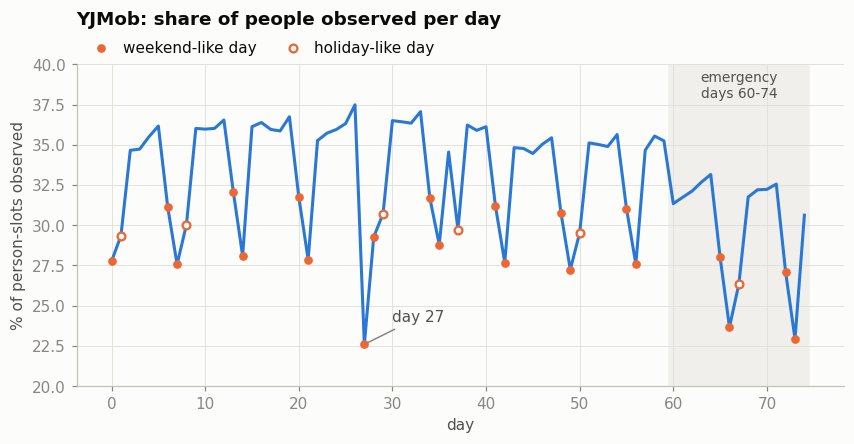

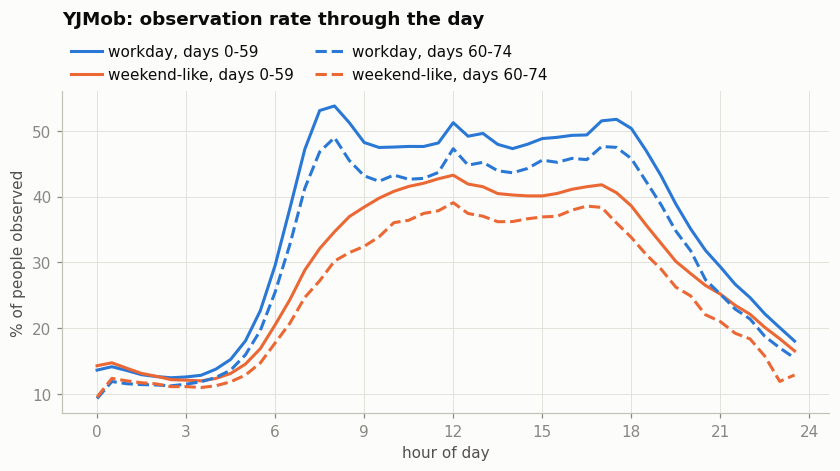

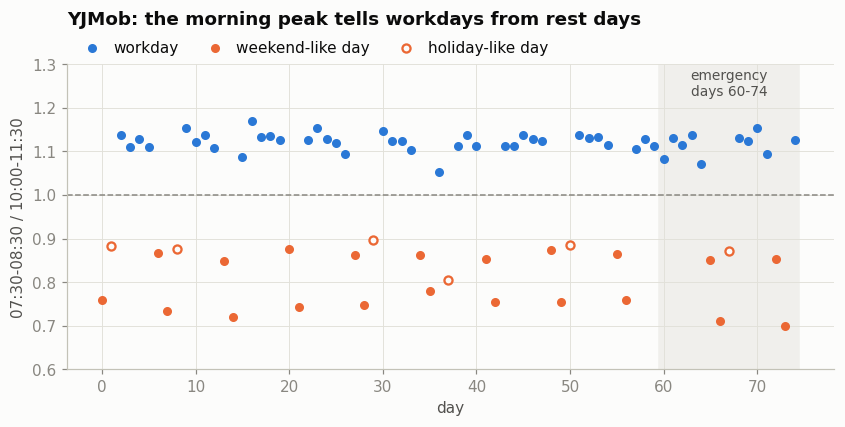

In [16]:
# figures again: f01 and f02 with the corrected day typing, f16 new (the check itself)
dt = pd.read_parquet(PROC / "day_table.parquet")
def save(fig, name): fig.savefig(FIG / f"{name}.png"); print("saved", name)
def legend_above(ax, ncol): ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=ncol, borderaxespad=0.2, handletextpad=0.4, columnspacing=1.4)
def band(ax, y): ax.axvspan(59.5, 74.5, color="#f0efec", zorder=0); ax.text(67, y, "emergency\ndays 60-74", color="#52514e", ha="center", va="top", fontsize=9)

fig, ax = plt.subplots(figsize=(9, 3.8)); band(ax, 39.6)
ax.plot(dt.d, dt.coverage * 100, color=C[0], lw=2)
ax.scatter(dt.d[dt.weekend], dt.coverage[dt.weekend] * 100, color=C[1], s=22, zorder=3, label="weekend-like day")
ax.scatter(dt.d[dt.holiday_like], dt.coverage[dt.holiday_like] * 100, facecolor="#fcfcfb", edgecolor=C[1], s=26, lw=1.5, zorder=3, label="holiday-like day")
ax.annotate("day 27", (27, dt.coverage[27] * 100), xytext=(30, 24), arrowprops=dict(arrowstyle="-", color="#898781"), color="#52514e")
ax.set(xlabel="day", ylabel="% of person-slots observed", ylim=(20, 40)); ax.set_title("YJMob: share of people observed per day", pad=26); legend_above(ax, 2)
save(fig, "f01_yjmob_coverage_by_day")

fig, ax = plt.subplots(figsize=(9, 3.8))
for lab, mask, col, ls in [("workday, days 0-59", dt.workday & ~dt.emergency, C[0], "-"), ("weekend-like, days 0-59", dt.weekend & ~dt.emergency, C[1], "-"),
                           ("workday, days 60-74", dt.workday & dt.emergency, C[0], "--"), ("weekend-like, days 60-74", dt.weekend & dt.emergency, C[1], "--")]:
    ax.plot(np.arange(N_SLOTS) / 2, M[mask.to_numpy()].mean(axis=0) * 100, color=col, ls=ls, lw=2, label=lab)
ax.set(xlabel="hour of day", ylabel="% of people observed", xticks=range(0, 25, 3)); ax.set_title("YJMob: observation rate through the day", pad=44); legend_above(ax, 2)
save(fig, "f02_yjmob_coverage_by_hour")

fig, ax = plt.subplots(figsize=(9, 3.6)); band(ax, 1.29); ax.axhline(1, color="#898781", lw=1, ls="--")
ax.scatter(dt.d[dt.workday], dt.morning_ratio[dt.workday], color=C[0], s=24, zorder=3, label="workday")
ax.scatter(dt.d[dt.weekend], dt.morning_ratio[dt.weekend], color=C[1], s=24, zorder=3, label="weekend-like day")
ax.scatter(dt.d[dt.holiday_like], dt.morning_ratio[dt.holiday_like], facecolor="#fcfcfb", edgecolor=C[1], s=28, lw=1.5, zorder=3, label="holiday-like day")
ax.set(xlabel="day", ylabel="07:30-08:30 / 10:00-11:30", ylim=(0.6, 1.3)); ax.set_title("YJMob: the morning peak tells workdays from rest days", pad=26); legend_above(ax, 3)
save(fig, "f16_yjmob_day_types")
plt.show()

## Figures redrawn

f01 and f02 replace the versions from notebook 01, and f16 is new. In f01 the weekend-like markers now follow the weekly rhythm through the emergency, and the six holiday-like days account for the dips that the weekly rhythm does not. In f02 the emergency curves are lower copies of the ordinary ones: the workday keeps its 08:00 peak. f16 shows the check that the day typing rests on: every workday is above the line, every weekend-like and holiday-like day is below it, on days 0-59 and on days 60-74 alike.

In [17]:
# outputs of this review
import datetime as dtm
for p in [ROOT / "code/prep.py", ROOT / "code/prep_v1.py", PROC / "day_table.parquet", PROC / "yjmob_analysis.parquet",
          FIG / "f01_yjmob_coverage_by_day.png", FIG / "f02_yjmob_coverage_by_hour.png", FIG / "f16_yjmob_day_types.png", ROOT / "logs/prep_log.json"]:
    s = p.stat(); print(f"{str(p.relative_to(ROOT)):45s} {s.st_size/1e6:8.2f} MB   {dtm.datetime.fromtimestamp(s.st_mtime):%Y-%m-%d %H:%M}")
print("\nworkdays 0-59:", dt.d[dt.workday & ~dt.emergency].tolist())
print("workdays 60-74:", dt.d[dt.workday & dt.emergency].tolist())

code/prep.py                                      0.01 MB   2026-09-17 17:09
code/prep_v1.py                                   0.01 MB   2026-09-17 17:09
data/processed/day_table.parquet                  0.01 MB   2026-09-17 17:10
data/processed/yjmob_analysis.parquet           161.78 MB   2026-09-17 17:10
figures/f01_yjmob_coverage_by_day.png             0.10 MB   2026-09-17 17:14
figures/f02_yjmob_coverage_by_hour.png            0.11 MB   2026-09-17 17:14
figures/f16_yjmob_day_types.png                   0.06 MB   2026-09-17 17:14
logs/prep_log.json                                0.00 MB   2026-09-17 17:10

workdays 0-59: [2, 3, 4, 5, 9, 10, 11, 12, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26, 30, 31, 32, 33, 36, 38, 39, 40, 43, 44, 45, 46, 47, 51, 52, 53, 54, 57, 58, 59]
workdays 60-74: [60, 61, 62, 63, 64, 68, 69, 70, 71, 74]


## Outputs

Corrected script code/prep.py (previous version kept as code/prep_v1.py), rebuilt data/processed/yjmob_analysis.parquet (17 columns, holiday_like added, phase and weekend corrected), new data/processed/day_table.parquet (75 rows), figures f01 and f02 replaced and f16 added. What changed in substance: the weekly phase is shifted by four days from day 60, six weekday-phase days are holiday-like, day 27 is a weekend-like day and not a weekday, and the emergency lowers the observation rate by 10 to 17% on every kind of day while the shape of the workday, including the 08:00 peak, stays the same. Two recording artefacts are documented and left in: a gap on day 66 at 23:00 and a thin 00:00 slot on days 60-74.